# 02 - Chignolin CV Transformer

In [21]:
# Requires: pip install -e .

import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from course_project.models.cv_core import CVCoreConfig, CVCoreInput, SharedCVCore
from course_project.utils import resolve_device

from course_project.peptide import (
    build_split_tensors,
    compute_norm_stats,
    ids_for_mutants,
    load_target_table,
)


### Loading mutant data

In [22]:
device = torch.device(resolve_device('cuda'))
force_train = False
print('device:', device)

# Data 
peptide_dir = Path('../data/peptide')
packed_path = peptide_dir / 'hlda_trajectories_compact.pt'
tm_csv = peptide_dir / 'Tm.csv'
mfpt_csv = peptide_dir / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv'
evalue_csv = peptide_dir / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv'

num_runs = 4
train_mutant_count = 20
val_mutant_count = 8
# exclude_mutants = {'Y0R', 'D2R'}
exclude_mutants = {}

history = 1
frames_per_traj = 20000

# Model and training parms
hidden_size = 190
CVs = 7
token_sizes = (200, 60, CVs)
heads = 1
transformer_layers = 1
dropout = 0.005
batch_size = 512
learning_rate = 1e-4
weight_decay = 0.0
cls_weight = 0.5
time_lag_steps = 0
time_lag_weight = 0
epochs = 30
eval_every = 2

w_spearman = 0.6
w_pearson = 0.4

target_df = load_target_table(tm_csv, mfpt_csv, evalue_csv)
target_mutants = set(target_df['mutant'].astype(str).tolist())

packed = torch.load(packed_path, weights_only=False)
x_raw = packed['x'].float()
time_all = packed['time'].float()
offsets = packed['traj_offsets'].long()
labels = packed['labels'].long()
mutants = list(packed['mutants'])

x_all = x_raw
n_feat = int(x_all.shape[1])


uniq_mutants = sorted({
    m for m in set(mutants)
    if str(m).strip().upper() not in exclude_mutants and str(m) in target_mutants
})
print('packed path:', packed_path)
print('feature count:', n_feat)
print('all usable mutants:', len(uniq_mutants))


device: cuda
packed path: ../data/peptide/hlda_trajectories_compact.pt
feature count: 29
all usable mutants: 37


In [23]:
class SequenceHistoryAdapter(nn.Module):
    # Treat each descriptor like a node token: token i sees the history of descriptor i.
    def __init__(self, feat_dim, history, hidden_size):
        super().__init__()
        self.in_proj = nn.Linear(history, hidden_size)
        self.desc_emb = nn.Parameter(torch.randn(feat_dim, hidden_size) * 0.01)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.in_proj.weight)
        if self.in_proj.bias is not None:
            nn.init.zeros_(self.in_proj.bias)
        nn.init.normal_(self.desc_emb, mean=0.0, std=0.01)

    def build_core_input(self, x_hist) -> CVCoreInput:
        x_desc = x_hist.transpose(1, 2)
        tokens = self.in_proj(x_desc) + self.desc_emb.unsqueeze(0)
        mask = torch.ones(tokens.size(0), tokens.size(1), dtype=torch.bool, device=tokens.device)
        return CVCoreInput(tokens=tokens, mask=mask, local_skip=tokens)


class ChignolinCVModel(nn.Module):
    def __init__(self, feat_dim, history, hidden, token_sizes, heads, token_layers, dropout):
        super().__init__()
        self.adapter = SequenceHistoryAdapter(feat_dim, history, hidden)
        self.core = SharedCVCore(
            CVCoreConfig(
                hidden_size=hidden,
                output_dim=1,
                transformer_layers=token_layers,
                transformer_heads=heads,
                transformer_dropout=dropout,
                token_sizes=token_sizes,
                use_local_skip=True,
            )
        )
        self.cls_head = nn.Sequential(
            nn.Linear(token_sizes[-1], hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.reset_parameters()

    def reset_parameters(self):
        for seq in (self.cls_head,):
            for module in seq.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        nn.init.zeros_(module.bias)

    def forward(self, x_hist):
        core_input = self.adapter.build_core_input(x_hist)
        output = self.core(core_input)
        cv = output.cv
        cls_logit = self.cls_head(cv).squeeze(-1)
        tau_pred = self.core.predict_tau(core_input).squeeze(-1)
        return output.prediction.squeeze(-1), tau_pred, cls_logit, cv


### Training 

The chignolin training came late, as just another experiment for the CV architecture. The training is a little different than 01 hence some of the training code is not shared and defined here.

In [24]:
def run_epoch(loader, train_mode=True):
    model.train(train_mode)
    loss_sum = 0.0
    dv_loss_sum = 0.0
    tau_loss_sum = 0.0
    cls_loss_sum = 0.0
    n = 0
    y_true = []
    y_prob = []

    for xh, y_dv, y_tau, y_cls, traj_id in loader:
        xh = xh.to(device)
        y_dv = y_dv.to(device)
        y_tau = y_tau.to(device)
        y_cls = y_cls.to(device)
        traj_id = traj_id.to(device)

        with torch.set_grad_enabled(train_mode):
            dv_pred, tau_pred, cls_logit, cv = model(xh)
            loss_dv = F.mse_loss(dv_pred, y_dv)
            if time_lag_steps > 0 and time_lag_weight > 0:
                loss_tau = F.mse_loss(tau_pred, y_tau)
                loss = loss_dv + time_lag_weight * loss_tau
            else:
                loss_tau = torch.zeros((), device=loss_dv.device)
                loss = loss_dv
            if cls_weight > 0:
                loss_cls = F.binary_cross_entropy_with_logits(cls_logit, y_cls)
                loss = loss + cls_weight * loss_cls
            else:
                loss_cls = torch.zeros((), device=loss_dv.device)
            if train_mode:
                opt.zero_grad()
                loss.backward()
                opt.step()

        b = xh.size(0)
        n += b
        loss_sum += loss.item() * b
        dv_loss_sum += loss_dv.item() * b
        tau_loss_sum += loss_tau.item() * b
        cls_loss_sum += loss_cls.item() * b
        y_true.append(y_cls.detach().cpu())
        y_prob.append(torch.sigmoid(cls_logit).detach().cpu())

    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    y_pred = (y_prob >= 0.5).astype(np.int64)

    out = {
        'loss': loss_sum / n,
        'dv_mse': dv_loss_sum / n,
        'tau_mse': tau_loss_sum / n,
        'cls_bce': cls_loss_sum / n,
        'cls_acc': float((y_pred == y_true).mean()) if cls_weight > 0 else float('nan'),
    }
    return out


@torch.no_grad()
def cv_summary_df_from_split(x_tensor, sample_df):
    model.eval()
    cv_rows = []
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False, drop_last=False)
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model(xh)
        cv_rows.append(cv.detach().cpu())
    cv_all = torch.cat(cv_rows, dim=0).numpy()
    cv_df = sample_df.reset_index(drop=True)
    base_cv_cols = []
    for i in range(cv_all.shape[1]):
        col = f'CV{i + 1}'
        cv_df[col] = cv_all[:, i]
        base_cv_cols.append(col)

    mean_df = cv_df.groupby('mutant', as_index=False)[base_cv_cols].mean()
    mean_df = mean_df.rename(columns={c: f'{c}_mean' for c in base_cv_cols})
    median_df = cv_df.groupby('mutant', as_index=False)[base_cv_cols].median()
    median_df = median_df.rename(columns={c: f'{c}_median' for c in base_cv_cols})
    return mean_df.merge(median_df, on='mutant', how='inner')

def merged_cv_target_for_split(x_tensor, sample_df):
    cv_df = cv_summary_df_from_split(x_tensor, sample_df)
    return cv_df.merge(target_df, on='mutant', how='inner')


@torch.no_grad()
def cv_frame_df_from_split(x_tensor, sample_df):
    model.eval()
    cv_rows = []
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False, drop_last=False)
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model(xh)
        cv_rows.append(cv.detach().cpu())
    cv_all = torch.cat(cv_rows, dim=0).numpy()
    cv_df = sample_df.reset_index(drop=True)
    for i in range(cv_all.shape[1]):
        cv_df[f'CV{i + 1}'] = cv_all[:, i]
    return cv_df


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size < 3:
        return float('nan')
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return float('nan')
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    if ss_tot <= 1e-12:
        return float('nan')
    return float(1.0 - ss_res / ss_tot)


def best_metric_from_merged(merged, metric):
    cv_cols = [c for c in merged.columns if c.startswith('CV') and (c.endswith('_mean') or c.endswith('_median'))]
    best = {'score': float('-inf'), 'r2': float('nan'), 'cv': None, 'n': 0, 'spearman': float('nan'), 'pearson': float('nan')}
    for cv in cv_cols:
        sub = merged[[cv, metric]].dropna()
        n = int(len(sub))
        if n < 3:
            continue
        s = float(sub[cv].corr(sub[metric], method='spearman'))
        p = float(sub[cv].corr(sub[metric], method='pearson'))
        r2 = fit_r2(sub[cv].to_numpy(), sub[metric].to_numpy())
        score = w_spearman * abs(s) + w_pearson * abs(p)
        if not np.isfinite(score):
            continue
        if score > best['score']:
            best = {'score': float(score), 'r2': float(r2), 'cv': cv, 'n': n, 'spearman': float(s), 'pearson': float(p)}
    return best


history_rows = []
val_metric_rows = []
selection_rows = []
selected_test_payload = {}
metrics = ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']
best_by_metric = {
    metric: {
        'score': float('-inf'),
        'r2': float('nan'),
        'epoch': None,
        'cv': None,
        'spearman': float('nan'),
        'pearson': float('nan'),
        'run_idx': None,
        'run_seed': None,
        'path': None,
    }
    for metric in metrics
}

run_dir = Path('../results') / 'chignolin_cv_transformer'
run_dir.mkdir(parents=True, exist_ok=True)
history_csv = run_dir / 'history.csv'
val_metric_csv = run_dir / 'val_metric_history.csv'
selection_csv = run_dir / 'selection_summary.csv'

need_train = force_train or not history_csv.exists() or not val_metric_csv.exists() or not selection_csv.exists()

if need_train:
    for run_idx in range(1, num_runs + 1):
        run_seed = int(torch.seed() % (2**32 - 1))
        random.seed(run_seed)
        np.random.seed(run_seed)
        torch.manual_seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        run_mutants = list(uniq_mutants)
        split_rng = np.random.default_rng(run_seed)
        split_rng.shuffle(run_mutants)
        train_mutants = list(run_mutants[:train_mutant_count])
        val_mutants = list(run_mutants[train_mutant_count:train_mutant_count + val_mutant_count])
        test_mutants = list(run_mutants[train_mutant_count + val_mutant_count:])

        train_ids = ids_for_mutants(mutants, train_mutants)
        val_ids = ids_for_mutants(mutants, val_mutants)
        test_ids = ids_for_mutants(mutants, test_mutants)

        x_mean, x_std, dv_mean, dv_std = compute_norm_stats(
            train_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, n_feat
        )

        train_x, train_dv, train_dv_tau, train_cls, train_traj_id, train_samples_df = build_split_tensors(
            train_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
        )
        val_x, val_dv, val_dv_tau, val_cls, val_traj_id, val_samples_df = build_split_tensors(
            val_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
        )
        test_x, test_dv, test_dv_tau, test_cls, test_traj_id, test_samples_df = build_split_tensors(
            test_ids, history, time_lag_steps, frames_per_traj, x_all, time_all, offsets, labels, mutants, x_mean, x_std, dv_mean, dv_std
        )

        train_loader = DataLoader(TensorDataset(train_x, train_dv, train_dv_tau, train_cls, train_traj_id), batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader = DataLoader(TensorDataset(val_x, val_dv, val_dv_tau, val_cls, val_traj_id), batch_size=batch_size, shuffle=False, drop_last=False)
        test_loader = DataLoader(TensorDataset(test_x, test_dv, test_dv_tau, test_cls, test_traj_id), batch_size=batch_size, shuffle=False, drop_last=False)

        print('train mutants:', len(train_mutants), 'val mutants:', len(val_mutants), 'test mutants:', len(test_mutants))
        print('samples:', len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

        model = ChignolinCVModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            heads=heads,
            token_layers=transformer_layers,
            dropout=dropout,
        ).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        run_ckpt_dir = run_dir / f'run_{run_idx:02d}'
        run_ckpt_dir.mkdir(parents=True, exist_ok=True)
        print('shared core token sizes:', model.core.token_sizes)
        print(f'time-lag steps={time_lag_steps} lambda={time_lag_weight}')

        for epoch in range(1, epochs + 1):
            tr = run_epoch(train_loader, train_mode=True)
            va = run_epoch(val_loader, train_mode=False)
            history_rows.append({
                'run_idx': run_idx,
                'run_seed': run_seed,
                'epoch': epoch,
                'train_loss': tr['loss'],
                'val_loss': va['loss'],
                'train_dv_mse': tr['dv_mse'],
                'val_dv_mse': va['dv_mse'],
                'train_tau_mse': tr['tau_mse'],
                'val_tau_mse': va['tau_mse'],
            })

            if epoch % eval_every != 0:
                print(
                    f"[run {run_idx:02d} ep {epoch:>3}/{epochs}] "
                    f"tr={tr['loss']:.3g} va={va['loss']:.3g} "
                    f"tau_mse={tr['tau_mse']:.3g}/{va['tau_mse']:.3g}"
                )
                continue

            merged_val = merged_cv_target_for_split(val_x, val_samples_df)
            ckpt_path = run_ckpt_dir / f'epoch_{epoch:04d}.pt'
            torch.save({'run_idx': run_idx, 'run_seed': run_seed, 'epoch': epoch, 'model_state_dict': model.state_dict()}, ckpt_path)

            best_text = 'none'
            best_score = float('-inf')
            for metric in metrics:
                best = best_metric_from_merged(merged_val, metric)
                val_metric_rows.append({
                    'run_idx': run_idx,
                    'run_seed': run_seed,
                    'epoch': epoch,
                    'metric': metric,
                    'val_best_score': float(best['score']),
                    'val_best_r2': float(best['r2']),
                    'val_best_cv': best['cv'],
                    'val_best_spearman': float(best['spearman']),
                    'val_best_pearson': float(best['pearson']),
                    'val_n': int(best['n']),
                })
                if np.isfinite(best['score']) and best['score'] > best_by_metric[metric]['score']:
                    best_by_metric[metric] = {
                        'score': float(best['score']),
                        'r2': float(best['r2']),
                        'epoch': epoch,
                        'cv': best['cv'],
                        'spearman': float(best['spearman']),
                        'pearson': float(best['pearson']),
                        'run_idx': run_idx,
                        'run_seed': run_seed,
                        'path': str(ckpt_path),
                    }
                if np.isfinite(best['score']) and best['score'] > best_score:
                    best_score = float(best['score'])
                    best_text = (
                        f"{metric}/{best['cv']} score={best['score']:.3g} "
                        f"R2={best['r2']:.3g} |S|={abs(best['spearman']):.3g} |P|={abs(best['pearson']):.3g}"
                    )

            print(
                f"[run {run_idx:02d} ep {epoch:>3}/{epochs}] "
                f"tr={tr['loss']:.3g} va={va['loss']:.3g} "
                f"tau_mse={tr['tau_mse']:.3g}/{va['tau_mse']:.3g} "
                f"best_cv={best_text}"
            )

    history_df = pd.DataFrame(history_rows)
    val_metric_history_df = pd.DataFrame(val_metric_rows)

    for metric in metrics:
        best = best_by_metric[metric]
        ckpt = torch.load(best['path'], map_location='cpu', weights_only=False)
        model = ChignolinCVModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            heads=heads,
            token_layers=transformer_layers,
            dropout=dropout,
        ).to(device)
        model.load_state_dict(ckpt['model_state_dict'])

        val_merged = merged_cv_target_for_split(val_x, val_samples_df)
        test_merged = merged_cv_target_for_split(test_x, test_samples_df)
        cv_col = best['cv']
        val_sub = val_merged[[cv_col, metric, 'mutant']].dropna()
        test_sub = test_merged[[cv_col, metric, 'mutant']].dropna()
        val_r2 = fit_r2(val_sub[cv_col].to_numpy(), val_sub[metric].to_numpy())
        test_r2 = fit_r2(test_sub[cv_col].to_numpy(), test_sub[metric].to_numpy())
        val_s = float(val_sub[cv_col].corr(val_sub[metric], method='spearman'))
        val_p = float(val_sub[cv_col].corr(val_sub[metric], method='pearson'))
        test_s = float(test_sub[cv_col].corr(test_sub[metric], method='spearman'))
        test_p = float(test_sub[cv_col].corr(test_sub[metric], method='pearson'))

        selection_rows.append({
            'metric': metric,
            'best_run': int(best['run_idx']),
            'run_seed': int(best['run_seed']),
            'best_epoch': int(best['epoch']),
            'best_cv': cv_col,
            'val_score': float(best['score']),
            'val_r2': val_r2,
            'val_spearman': val_s,
            'val_pearson': val_p,
            'test_r2': test_r2,
            'test_spearman': test_s,
            'test_pearson': test_p,
            'test_n': int(len(test_sub)),
            'checkpoint_path': best['path'],
        })
        selected_test_payload[metric] = {
            'best_run': int(best['run_idx']),
            'run_seed': int(best['run_seed']),
            'best_epoch': int(best['epoch']),
            'cv': cv_col,
            'val_merged': val_merged,
            'test_merged': test_merged,
            'val_score': float(best['score']),
            'val_r2': val_r2,
            'val_spearman': val_s,
            'val_pearson': val_p,
            'test_r2': test_r2,
            'test_spearman': test_s,
            'test_pearson': test_p,
        }

    selection_summary_df = pd.DataFrame(selection_rows)
    history_df.to_csv(history_csv, index=False)
    val_metric_history_df.to_csv(val_metric_csv, index=False)
    selection_summary_df.to_csv(selection_csv, index=False)
    print(selection_summary_df)
else:
    print('using existing peptide run from', run_dir)
    history_df = pd.read_csv(history_csv)
    val_metric_history_df = pd.read_csv(val_metric_csv)
    selection_summary_df = pd.read_csv(selection_csv)
    for _, row in selection_summary_df.iterrows():
        metric = str(row['metric'])
        ckpt = torch.load(row['checkpoint_path'], map_location='cpu', weights_only=False)
        model = ChignolinCVModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            heads=heads,
            token_layers=transformer_layers,
            dropout=dropout,
        ).to(device)
        model.load_state_dict(ckpt['model_state_dict'])
        val_merged = merged_cv_target_for_split(val_x, val_samples_df)
        test_merged = merged_cv_target_for_split(test_x, test_samples_df)
        selected_test_payload[metric] = {
            'best_run': int(row['best_run']),
            'run_seed': int(row['run_seed']),
            'best_epoch': int(row['best_epoch']),
            'cv': str(row['best_cv']),
            'val_merged': val_merged,
            'test_merged': test_merged,
            'val_score': float(row['val_score']),
            'val_r2': float(row['val_r2']),
            'val_spearman': float(row['val_spearman']),
            'val_pearson': float(row['val_pearson']),
            'test_r2': float(row['test_r2']),
            'test_spearman': float(row['test_spearman']),
            'test_pearson': float(row['test_pearson']),
        }
    first_row = selection_summary_df.iloc[0]
    ckpt = torch.load(first_row['checkpoint_path'], map_location='cpu', weights_only=False)
    model = ChignolinCVModel(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        token_sizes=token_sizes,
        heads=heads,
        token_layers=transformer_layers,
        dropout=dropout,
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])

if need_train and not selection_summary_df.empty:
    first_row = selection_summary_df.iloc[0]
    ckpt = torch.load(first_row['checkpoint_path'], map_location='cpu', weights_only=False)
    model = ChignolinCVModel(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        token_sizes=token_sizes,
        heads=heads,
        token_layers=transformer_layers,
        dropout=dropout,
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])


using existing peptide run from ../results/chignolin_cv_transformer


### Analysis

The training target of the model, dV doesn't refelect entierly how well the CVs represent our metrics. That's why over all epochs we select the best model producing CVs that correlate best to the validation sample metics (mfpt, Tm, eigenvalue..)

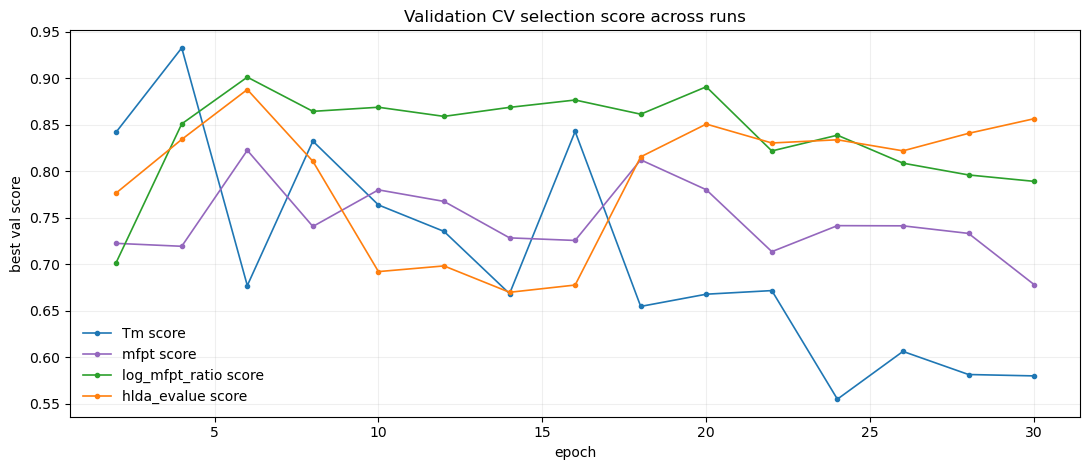

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for metric, color in [('Tm', 'tab:blue'), ('mfpt', 'tab:purple'), ('log_mfpt_ratio', 'tab:green'), ('hlda_evalue', 'tab:orange')]:
    sub = val_metric_history_df[val_metric_history_df['metric'] == metric]
    best_per_epoch = sub.groupby('epoch', as_index=False)[['val_best_score', 'val_best_r2']].max().sort_values('epoch')
    ax.plot(best_per_epoch['epoch'], best_per_epoch['val_best_score'], marker='o', ms=3, lw=1.2, color=color, label=f'{metric} score')
ax.set_xlabel('epoch')
ax.set_ylabel('best val score')
ax.set_title('Validation CV selection score across runs')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

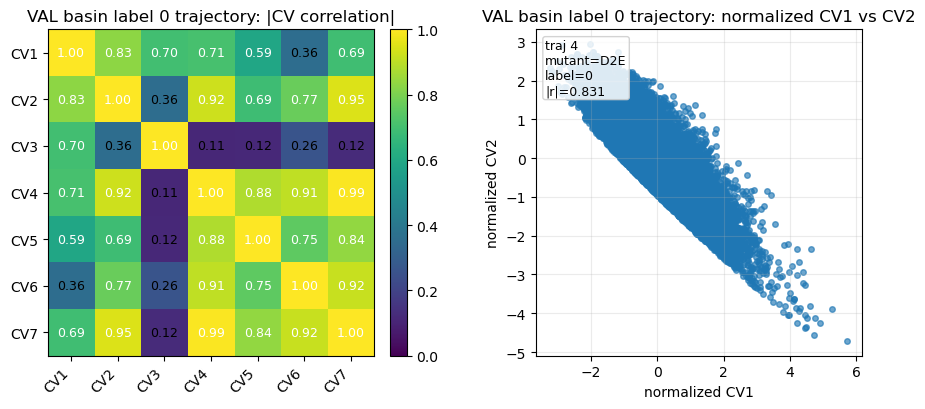

saved: ../results/chignolin_cv_transformer/chignolin_val_single_label0_cv_view.png


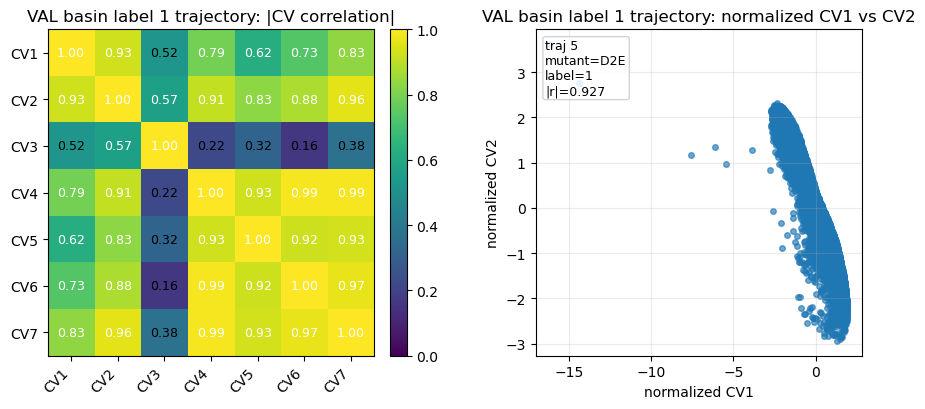

saved: ../results/chignolin_cv_transformer/chignolin_val_single_label1_cv_view.png


In [26]:
frame_cv_df = cv_frame_df_from_split(val_x, val_samples_df)
cv_cols = [c for c in frame_cv_df.columns if c.startswith('CV')]
assert len(cv_cols) >= 2
c1, c2 = cv_cols[0], cv_cols[1]

traj_label_df = val_samples_df[['traj_id']].drop_duplicates()
traj_label_df['label'] = [int(labels[int(tid)].item()) for tid in traj_label_df['traj_id']]
traj_to_mutant = val_samples_df[['traj_id', 'mutant']].drop_duplicates().reset_index(drop=True)
traj_label_df = traj_label_df.merge(traj_to_mutant, on='traj_id', how='left')

label0_traj = int(traj_label_df.loc[traj_label_df['label'] == 0, 'traj_id'].iloc[0])
label1_traj = int(traj_label_df.loc[traj_label_df['label'] == 1, 'traj_id'].iloc[0])

def normalize_pair(sub, xcol, ycol):
    x = sub[xcol].to_numpy(dtype=float)
    y = sub[ycol].to_numpy(dtype=float)
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return x, y

def plot_one_traj(traj_id, out_name, panel_title):
    sub = frame_cv_df[frame_cv_df['traj_id'] == int(traj_id)].reset_index(drop=True)
    row = traj_label_df[traj_label_df['traj_id'] == int(traj_id)].iloc[0]
    corr = np.abs(sub[cv_cols].corr(method='pearson').to_numpy(dtype=float))
    r = abs(float(sub[c1].corr(sub[c2], method='pearson')))
    x, y = normalize_pair(sub, c1, c2)

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
    im = axes[0].imshow(corr, vmin=0.0, vmax=1.0, cmap='viridis')
    axes[0].set_xticks(range(len(cv_cols)))
    axes[0].set_yticks(range(len(cv_cols)))
    axes[0].set_xticklabels(cv_cols, rotation=45, ha='right')
    axes[0].set_yticklabels(cv_cols)
    axes[0].set_title(f'{panel_title}: |CV correlation|')
    for i in range(len(cv_cols)):
        for j in range(len(cv_cols)):
            axes[0].text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=9, color='white' if corr[i, j] > 0.55 else 'black')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].scatter(x, y, color='tab:blue', alpha=0.65, s=16)
    axes[1].set_title(f'{panel_title}: normalized {c1} vs {c2}')
    axes[1].text(
        0.03, 0.97,
        f'traj {traj_id}\nmutant={row["mutant"]}\nlabel={int(row["label"])}\n|r|={r:.3f}',
        transform=axes[1].transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='0.8'),
    )
    axes[1].set_xlabel(f'normalized {c1}')
    axes[1].set_ylabel(f'normalized {c2}')
    axes[1].grid(alpha=0.25)
    axes[1].set_box_aspect(1)

    fig.tight_layout()
    out_path = run_dir / out_name
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', out_path)

plot_one_traj(label0_traj, 'chignolin_val_single_label0_cv_view.png', 'VAL basin label 0 trajectory')
plot_one_traj(label1_traj, 'chignolin_val_single_label1_cv_view.png', 'VAL basin label 1 trajectory')


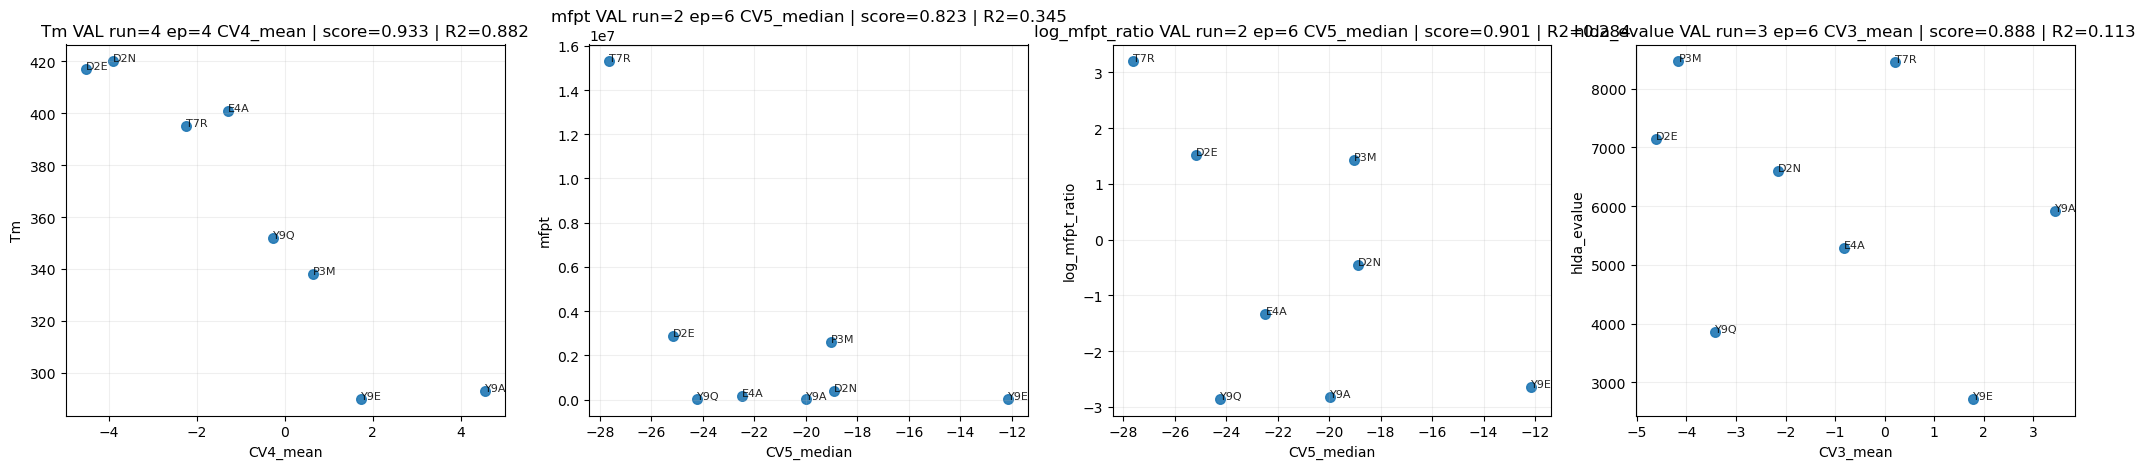

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(21, 4.8))
for ax, metric in zip(np.asarray(axes).reshape(-1), ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']):
    payload = selected_test_payload.get(metric)
    if payload is None:
        ax.set_axis_off()
        continue
    cv = payload['cv']
    sub = payload['val_merged'][[cv, metric, 'mutant']].dropna()
    ax.scatter(sub[cv], sub[metric], s=48, alpha=0.9)
    for _, r in sub.iterrows():
        ax.text(r[cv], r[metric], str(r['mutant']), fontsize=8, alpha=0.85)
    ax.set_title(
        f"{metric} VAL run={payload['best_run']} ep={payload['best_epoch']} {cv} "
        f"| score={payload['val_score']:.3f} | R2={payload['val_r2']:.3f}"
    )
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()



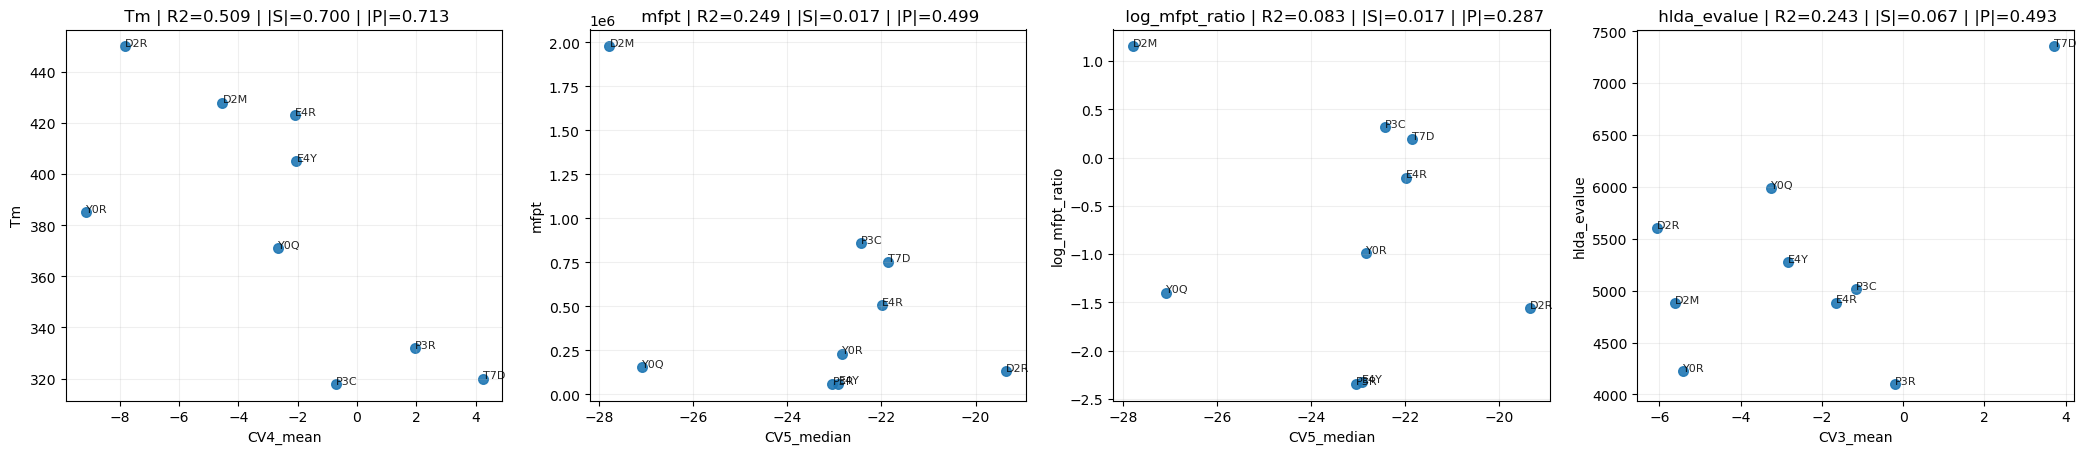

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(21, 4.8))
for ax, metric in zip(np.asarray(axes).reshape(-1), ['Tm', 'mfpt', 'log_mfpt_ratio', 'hlda_evalue']):
    payload = selected_test_payload.get(metric)
    if payload is None:
        ax.set_axis_off()
        continue
    cv = payload['cv']
    sub = payload['test_merged'][[cv, metric, 'mutant']].dropna()
    ax.scatter(sub[cv], sub[metric], s=48, alpha=0.9)
    for _, r in sub.iterrows():
        ax.text(r[cv], r[metric], str(r['mutant']), fontsize=8, alpha=0.85)
    ax.set_title(
        # f" run={payload['best_run']} ep={payload['best_epoch']} {cv} "
        f" {metric} | R2={payload['test_r2']:.3f} | |S|={abs(payload['test_spearman']):.3f} | |P|={abs(payload['test_pearson']):.3f}"
    )
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

